# 01 — Analisi Preliminare

Notebook dedicato al caricamento del dataset, pulizia delle colonne e prima analisi esplorativa.

**Sprint 1 | Settimana 1**

In [120]:
# Librerie principali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Impostazioni grafici
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Librerie importate correttamente")

Librerie importate correttamente


## US-01 · Caricamento e Prima Ispezione del Dataset

In [121]:
import os
from datasets import load_dataset
import pandas as pd

# Carica il dataset da Hugging Face (train + validation + test)
dataset = load_dataset("aai510-group1/telco-customer-churn")

df = pd.concat([
    dataset['train'].to_pandas(),
    dataset['validation'].to_pandas(),
    dataset['test'].to_pandas()
], ignore_index=True)

print(df.shape)  # (7043, 52)
print("Dataset caricato correttamente")

# Salvataggio in data/raw/ — eseguire solo la prima volta
raw_path = os.path.abspath(os.path.join("..", "data", "raw", "telco_churn.csv"))
df.to_csv(raw_path, index=False)
print(f"✅ Dataset raw salvato in: {raw_path}")

(7043, 52)
Dataset caricato correttamente
✅ Dataset raw salvato in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\data\raw\telco_churn.csv


In [122]:
# Verifica dimensioni
print(f"Righe: {df.shape[0]}")
print(f"Colonne: {df.shape[1]}")

# Tipi di dato per ogni colonna
print("\nTipi di dato:")
print(df.dtypes)

Righe: 7043
Colonne: 52

Tipi di dato:
Age                                    int64
Avg Monthly GB Download                int64
Avg Monthly Long Distance Charges    float64
Churn                                  int64
Churn Category                           str
Churn Reason                             str
Churn Score                            int64
City                                     str
CLTV                                   int64
Contract                                 str
Country                                  str
Customer ID                              str
Customer Status                          str
Dependents                             int64
Device Protection Plan                 int64
Gender                                   str
Internet Service                       int64
Internet Type                            str
Lat Long                                 str
Latitude                             float64
Longitude                            float64
Married         

In [123]:
# Prime 5 righe
print("Prime 5 righe:")
df.head()

Prime 5 righe:


,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,...,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code
0,72,4,19.44,0,NaN,NaN,51,San Mateo,4849,Two Year,...,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403
1,27,59,45.62,0,NaN,NaN,27,Sutter Creek,3715,Month-to-Month,...,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685
2,59,0,16.07,0,NaN,NaN,59,Santa Cruz,5092,Month-to-Month,...,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064
3,25,27,0.00,0,NaN,NaN,49,Brea,2068,One Year,...,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823
4,31,21,17.22,1,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,...,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117


In [124]:
df.tail()

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,...,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code
7038,33,12,10.67,0,NaN,NaN,53,Clayton,4847,Month-to-Month,...,1,29,2878.75,0,309.43,0.0,3188.18,0,1,94517
7039,36,30,30.44,0,NaN,NaN,45,Nicolaus,5470,Two Year,...,1,59,5655.45,0,1795.96,0.0,7451.41,0,1,95659
7040,57,24,4.51,0,NaN,NaN,74,Walnut Creek,4471,Two Year,...,1,61,5175.30,0,275.11,0.0,5450.41,0,1,94596
7041,35,24,47.06,0,NaN,NaN,70,Valyermo,5445,Two Year,...,0,30,1653.85,0,1411.80,0.0,3065.65,0,1,93563
7042,54,24,12.85,0,NaN,NaN,70,Rancho Cucamonga,5065,Two Year,...,1,72,7998.80,70,925.20,0.0,8994.00,0,0,91701


In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Avg Monthly GB Download            7043 non-null   int64  
 2   Avg Monthly Long Distance Charges  7043 non-null   float64
 3   Churn                              7043 non-null   int64  
 4   Churn Category                     1869 non-null   str    
 5   Churn Reason                       1869 non-null   str    
 6   Churn Score                        7043 non-null   int64  
 7   City                               7043 non-null   str    
 8   CLTV                               7043 non-null   int64  
 9   Contract                           7043 non-null   str    
 10  Country                            7043 non-null   str    
 11  Customer ID                        7043 non-null   str    
 12  Cus

## US-02 · Rimozione delle Colonne Leaky e Inutili

# Cos'è il Data Leakage?
Il data leakage si verifica quando il modello riceve informazioni che nella realtà
non sarebbero disponibili al momento della predizione.

**Esempio concreto da questo dataset**: immagina di essere un analista del 
Dipartimento Retention il lunedì mattina. Hai davanti i dati di un cliente 
ancora attivo. Puoi vedere la sua età, il tipo di contratto, la spesa mensile. 
Non puoi vedere il motivo per cui se ne andrà (`Churn Reason`) o la categoria 
del suo abbandono (`Churn Category`) — perché non è ancora andato via.
Usare queste informazioni nel modello sarebbe come consegnare le risposte 
durante un esame: il modello sembrerebbe perfetto, ma nella realtà fallirebbe.

In [126]:
print(df.nunique().sort_values())

Country                                 1
Quarter                                 1
State                                   1
Churn                                   2
Dependents                              2
Multiple Lines                          2
Gender                                  2
Device Protection Plan                  2
Online Backup                           2
Partner                                 2
Paperless Billing                       2
Online Security                         2
Phone Service                           2
Premium Tech Support                    2
Married                                 2
Internet Service                        2
Streaming Movies                        2
Streaming Music                         2
Referred a Friend                       2
Senior Citizen                          2
Under 30                                2
Unlimited Data                          2
Streaming TV                            2
Internet Type                     

### Premessa metodologica
Prima di procedere con qualsiasi analisi, il team ha identificato e rimosso 
le colonne che non possono essere utilizzate come feature predittive. Questa 
fase è critica per garantire che il modello rifletta fedelmente le informazioni 
disponibili al momento della predizione nella realtà operativa aziendale.

### Colonne rimosse per Data Leakage
Le seguenti colonne contengono informazioni disponibili solo *dopo* che il cliente 
ha già abbandonato il servizio. Includerle nel modello invaliderebbe completamente 
i risultati, in quanto il modello "conoscerebbe la risposta in anticipo".

| Colonna | Motivazione |
|---|---|
| Churn Score | Probabilità di abbandono già calcolata da sistema esterno |
| Churn Category | Categoria del motivo di abbandono — disponibile solo post-abbandono |
| Churn Reason | Motivo specifico dell'abbandono — disponibile solo post-abbandono |
| Customer Status | Stato finale del cliente — equivalente al target |

### Colonne rimosse per assenza di valore predittivo
| Colonna | Motivazione |
|---|---|
| Customer ID | Identificatore univoco del cliente — non porta informazione predittiva |
| Country | Valore costante (United States) — nessuna varianza nel dataset |
| State | Valore costante (California) — nessuna varianza nel dataset |
| Quarter | Valore costante (Q3) — nessuna varianza nel dataset |
| Lat Long | Colonna ridondante — Latitude e Longitude già presenti separatamente |
| Under 30 | Ridondante con la colonna Age, già inclusa nel dataset |

In [127]:
colonne_leaky = [
    "Churn Score",      
    "Churn Category",   
    "Churn Reason",     
    "Customer Status"   
]

df = df.drop(columns=colonne_leaky)
print(f"Colonne rimosse per data leakage: {len(colonne_leaky)}")
print(f"Shape dopo rimozione leaky: {df.shape}")

Colonne rimosse per data leakage: 4
Shape dopo rimozione leaky: (7043, 48)


In [128]:
colonne_inutili = [
    "Customer ID",  
    "Country",      
    "State",        
    "Quarter",      
    "Lat Long",     
    "Under 30"      
]

df = df.drop(columns=colonne_inutili)
print(f"Colonne rimosse per assenza di valore predittivo: {len(colonne_inutili)}")
print(f"Shape dopo rimozione colonne inutili: {df.shape}")

Colonne rimosse per assenza di valore predittivo: 6
Shape dopo rimozione colonne inutili: (7043, 42)


### Decisione sulle colonne "grigie"

Dopo valutazione del team, abbiamo deciso di procedere come segue:

| Colonna | Decisione | Motivazione |
|---|---|---|
| Satisfaction Score | Rimossa | Informazione raccolta prevalentemente dopo l'abbandono del cliente — parzialmente leaky |
| CLTV | Mantenuta | Valore economico calcolato a priori su tutti i clienti attivi — feature legittima e informativa |
| City | Rimossa | 1106 categorie uniche — introdurrebbe rumore nel modello senza apportare valore predittivo |
| Zip Code | Rimossa | Ridondante con Population e con troppi valori unici per essere gestita direttamente |
| Latitude | Rimossa | Coordinata geografica non interpretabile direttamente dal modello senza elaborazioni aggiuntive |
| Longitude | Rimossa | Coordinata geografica non interpretabile direttamente dal modello senza elaborazioni aggiuntive |
| Population | Mantenuta | Proxy della densità demografica della zona — fornisce informazioni sul contesto socioeconomico del cliente |

In [129]:
colonne_grigie = [
    "Satisfaction Score",
    "City",              
    "Zip Code",          
    "Latitude",          
    "Longitude"          
]

df = df.drop(columns=colonne_grigie)
print(f"Colonne rimosse dopo valutazione: {len(colonne_grigie)}")
print(f"Shape dopo rimozione colonne grigie: {df.shape}")

Colonne rimosse dopo valutazione: 5
Shape dopo rimozione colonne grigie: (7043, 37)


### Separazione della variabile target

La colonna `Churn` rappresenta la variabile target del progetto:
- `0` → il cliente è rimasto
- `1` → il cliente ha abbandonato il servizio

Viene separata dalle feature per essere utilizzata come variabile dipendente 
nella fase di modellazione.

In [130]:
y = df["Churn"]
X = df.drop(columns=["Churn"])

print(f"Feature (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nDistribuzione target:")
print(y.value_counts())
print(f"Percentuale churn: {y.mean()*100:.1f}%")

Feature (X): (7043, 36)
Target (y): (7043,)

Distribuzione target:
Churn
0    5174
1    1869
Name: count, dtype: int64
Percentuale churn: 26.5%


### Riepilogo della pulizia

| Fase | Colonne rimosse | Shape risultante |
|---|---|---|
| Dataset originale | — | (7043, 52) |
| Rimozione leaky | 4 | (7043, 48) |
| Rimozione inutili | 6 | (7043, 42) |
| Rimozione colonne grigie | 5 | (7043, 37) |
| Separazione target | 1 | X: (7043, 36) |

**Nota sul bilanciamento delle classi**: il dataset presenta uno sbilanciamento
con il 26.5% di clienti churned. Per questa ragione nelle fasi successive 
verrà utilizzato il **F1-Score** come metrica principale di valutazione, 
e non la semplice Accuracy.

# US-03 · Rinomina delle Variabili

## Per prima cosa andiamo a visionare i nomi delle colonne

In [131]:
print(df.columns.tolist())

['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Churn', 'CLTV', 'Contract', 'Dependents', 'Device Protection Plan', 'Gender', 'Internet Service', 'Internet Type', 'Married', 'Monthly Charge', 'Multiple Lines', 'Number of Dependents', 'Number of Referrals', 'Offer', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Payment Method', 'Phone Service', 'Population', 'Premium Tech Support', 'Referred a Friend', 'Senior Citizen', 'Streaming Movies', 'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue', 'Unlimited Data']


## Prepariamo la lista dei nuovi nomi in snake_case nel prepocessing.py ed avviamo la rinomina qui

In [132]:
import sys
import os

# Risale di un livello (da notebooks/ alla root del progetto)
# così Python trova la cartella src/
sys.path.append(os.path.abspath(".."))

from src.preprocessing import rename_columns

df = rename_columns(df)
print(df.columns.tolist())

['age', 'avg_monthly_gb_download', 'avg_monthly_ld_charges', 'churn', 'cltv', 'contract', 'dependents', 'device_protection_plan', 'gender', 'internet_service', 'internet_type', 'married', 'monthly_charge', 'multiple_lines', 'num_dependents', 'num_referrals', 'offer', 'online_backup', 'online_security', 'paperless_billing', 'partner', 'payment_method', 'phone_service', 'population', 'premium_tech_support', 'referred_a_friend', 'senior_citizen', 'streaming_movies', 'streaming_music', 'streaming_tv', 'tenure_months', 'total_charges', 'total_extra_data_charges', 'total_ld_charges', 'total_refunds', 'total_revenue', 'unlimited_data']


## Andiamo a verificare che non siano presenti maiuscole o spazi così che tutto risulti in snake_case

In [133]:
assert all(' ' not in col for col in df.columns), "Trovati spazi nei nomi colonna!"
assert all(col == col.lower() for col in df.columns), "Trovate maiuscole nei nomi colonna!"
print("✅ Tutti i nomi colonna sono validi")

✅ Tutti i nomi colonna sono validi


# US-04 · Controllo dei Duplicati

In [134]:
# Conta le righe duplicate — una riga è duplicata se tutti i valori
# di tutte le colonne sono identici a quelli di un'altra riga
duplicati = df.duplicated().sum()
totale = df.shape[0]

print(f"Righe duplicate: {duplicati}")
print(f"Totale righe: {totale}")
print(f"Percentuale duplicati: {duplicati / totale * 100:.2f}%")

Righe duplicate: 0
Totale righe: 7043
Percentuale duplicati: 0.00%


In [135]:
# Facciamo però un controllo sui duplicati parziali basati sulle colonne chiave del cliente
colonne_chiave = ['age', 'gender', 'tenure_months', 'monthly_charge', 'total_charges']

duplicati_parziali = df.duplicated(subset=colonne_chiave).sum()
print(f"Duplicati su colonne chiave: {duplicati_parziali}")

Duplicati su colonne chiave: 4


In [136]:
# Visualizza le righe con profilo identico sulle colonne chiave
mask = df.duplicated(subset=colonne_chiave, keep=False)
df[mask][colonne_chiave + ['contract', 'payment_method', 'churn']].sort_values(colonne_chiave)

,age,gender,tenure_months,monthly_charge,total_charges,contract,payment_method,churn
3378,31,Male,1,19.75,19.75,Month-to-Month,Credit Card,0
4234,31,Male,1,19.75,19.75,Month-to-Month,Bank Withdrawal,0
482,40,Female,1,25.25,25.25,Month-to-Month,Bank Withdrawal,0
6862,40,Female,1,25.25,25.25,Month-to-Month,Bank Withdrawal,0
1003,40,Male,1,19.65,19.65,Month-to-Month,Bank Withdrawal,0
3214,40,Male,1,19.65,19.65,Month-to-Month,Credit Card,0
4855,62,Male,1,44.00,44.00,Month-to-Month,Bank Withdrawal,0
6382,62,Male,1,44.00,44.00,Month-to-Month,Bank Withdrawal,0


### Osservazioni US-04 — Controllo Duplicati

**Duplicati esatti (tutte le colonne identiche):** 0 — nessun cliente registrato due volte.

**Duplicati parziali su colonne chiave:** 4 coppie di clienti con età, genere, 
tenure, spesa mensile e totale identici.

Analisi delle coppie:
- Le coppie hanno `tenure_months` = 1, quindi sono clienti nuovissimi — è plausibile
  che clienti diversi abbiano caratteristiche identiche all'inizio del contratto
- Il metodo di pagamento è diverso tra i membri di ogni coppia (es. Credit Card vs Bank Withdrawal)
- Il valore di `churn` è 0 per tutti — non introducono distorsione nella variabile target

**Conclusione:** non si tratta di veri duplicati ma di clienti distinti con profilo 
simile. Nessuna riga viene rimossa. Il dataset rimane a 7.043 righe.

 # US-05 · Analisi dei Missing Values

## Andiamo a verificare in quante colonne sono presenti dei valori mancanti

In [137]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False))

               missing_count  missing_pct
offer                   3877        55.05
internet_type           1526        21.67


## Andiamo a verificare che tipo di valori mancanti ci sono nelle colonne

In [138]:
print(df['offer'].value_counts(dropna=False))
print("---")
print(df['internet_type'].value_counts(dropna=False))

offer
NaN        3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64
---
internet_type
Fiber Optic    3035
DSL            1652
NaN            1526
Cable           830
Name: count, dtype: int64


## Strategia gestione missing values

- **offer**: il 55% di NaN indica che il cliente non ha ricevuto alcuna offerta → sostituiamo con `'No Offer'`
- **internet_type**: il NaN indica che il cliente non dispone di internet → sostituiamo con `'No Internet'`

In [139]:
from src.preprocessing import handle_missing_values

df = handle_missing_values(df)

# Verifica che non ci siano più missing
assert df.isnull().sum().sum() == 0, "Ci sono ancora missing values!"
print("✅ Nessun missing value nel dataset")

✅ Nessun missing value nel dataset


## Salvataggio del data in Dataset pulito

In [140]:
import os

# Costruisce il percorso assoluto in modo automatico partendo dalla posizione del notebook
processed_path = os.path.abspath(os.path.join("..", "data", "processed", "data_clean.csv"))

# Salvataggio dataset pulito — una volta sola alla fine del preprocessing
df.to_csv(processed_path, index=False)
print(f"✅ Dataset pulito salvato in: {processed_path}")
print(f"   Righe: {df.shape[0]}")
print(f"   Colonne: {df.shape[1]}")

✅ Dataset pulito salvato in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\data\processed\data_clean.csv
   Righe: 7043
   Colonne: 37


## US-06 · Distribuzione della Variabile Target

In [141]:
# Conteggio valori e percentuali della variabile target
conteggio = df['churn'].value_counts()
percentuali = df['churn'].value_counts(normalize=True) * 100

print("Distribuzione target:")
print(f"  Clienti rimasti  (0): {conteggio[0]} ({percentuali[0]:.1f}%)")
print(f"  Clienti churned  (1): {conteggio[1]} ({percentuali[1]:.1f}%)")

Distribuzione target:
  Clienti rimasti  (0): 5174 (73.5%)
  Clienti churned  (1): 1869 (26.5%)


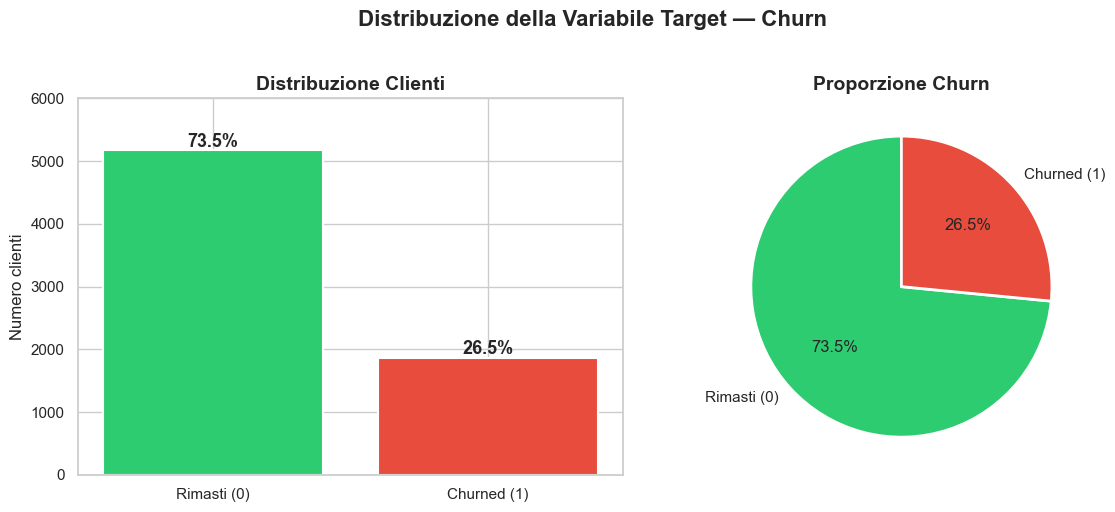

✅ Grafico salvato in: c:\Users\Giada Jenny Qafalia\Desktop\develhope\Progetto_team\telco-churn-ml\outputs\figures\06_distribuzione_target.png


In [142]:
import os

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Grafico a barre ---
colori = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Rimasti (0)', 'Churned (1)'], 
                    [conteggio[0], conteggio[1]], 
                    color=colori, edgecolor='white', linewidth=1.5)

# Aggiunge le percentuali sopra le barre
for bar, pct in zip(bars, [percentuali[0], percentuali[1]]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50,
                 f'{pct:.1f}%',
                 ha='center', fontsize=13, fontweight='bold')

axes[0].set_title('Distribuzione Clienti', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Numero clienti')
axes[0].set_ylim(0, 6000)

# --- Grafico a torta ---
axes[1].pie([conteggio[0], conteggio[1]],
            labels=['Rimasti (0)', 'Churned (1)'],
            colors=colori,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

axes[1].set_title('Proporzione Churn', fontsize=14, fontweight='bold')

plt.suptitle('Distribuzione della Variabile Target — Churn', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Salvataggio
figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "06_distribuzione_target.png"))
plt.savefig(figures_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Grafico salvato in: {figures_path}")

### Osservazioni US-06 — Distribuzione della Variabile Target

- **Clienti rimasti (0):** 5.174 (73.5%)
- **Clienti churned (1):** 1.869 (26.5%)

**Sbilanciamento delle classi:**
Il dataset è sbilanciato — circa 3 clienti su 4 non hanno abbandonato il servizio.
Un modello che predice sempre "rimasto" avrebbe una Accuracy dell'73.5% 
ma sarebbe completamente inutile — non identificherebbe mai un cliente a rischio.

**Implicazioni per la modellazione:**
- Useremo **F1-Score** come metrica principale, non l'Accuracy
- I modelli verranno addestrati con `class_weight='balanced'` per compensare lo sbilanciamento
- Lo split train/test sarà **stratificato** per mantenere le stesse proporzioni

# US-07 · Analisi Descrittiva delle Variabili Numeriche

## Riepilogo Statistico

Il Dipartimento Retention & Analytics richiede un riepilogo statistico delle variabili numeriche
per verificare la plausibilità dei dati e individuare eventuali anomalie prima della fase di modellazione.

### Statistiche descrittive 

In [143]:
# Selezione variabili numeriche
num_cols = X.select_dtypes(include='number').columns.tolist()

# Riepilogo statistico: media, mediana, deviazione standard, minimo e massimo
desc = X[num_cols].describe().T[['mean', '50%', 'std', 'min', 'max']]
desc.columns = ['Media', 'Mediana', 'Dev. Std.', 'Minimo', 'Massimo']
desc = desc.round(2)

print(f"Variabili numeriche analizzate: {len(num_cols)}")
display(desc)

Variabili numeriche analizzate: 31


,Media,Mediana,Dev. Std.,Minimo,Massimo
Age,46.51,46.00,16.75,19.00,80.00
Avg Monthly GB Download,20.52,17.00,20.42,0.00,85.00
Avg Monthly Long Distance Charges,22.96,22.89,15.45,0.00,49.99
CLTV,4400.30,4527.00,1183.06,2003.00,6500.00
Dependents,0.23,0.00,0.42,0.00,1.00
Device Protection Plan,0.34,0.00,0.48,0.00,1.00
Internet Service,0.78,1.00,0.41,0.00,1.00
Married,0.48,0.00,0.50,0.00,1.00
Monthly Charge,64.76,70.35,30.09,18.25,118.75
Multiple Lines,0.42,0.00,0.49,0.00,1.00


### Osservazioni US-07 — Statistiche Descrittive

**Variabili continue chiave**

| Variabile | Osservazione |
|---|---|
| `Age` | Range 19–80 anni, media 46.5. Distribuzione plausibile per una base clienti telefonici. |
| `Tenure in Months` | Il 50% dei clienti ha meno di 29 mesi di anzianità. La media (32) è superiore alla mediana, segnale di una distribuzione asimmetrica verso destra: pochi clienti con tenure molto lunga alzano la media. |
| `Monthly Charge` | La mediana (70.35) è superiore alla media (64.76): più della metà dei clienti paga sopra la media. Clienti con canoni molto bassi abbassano il valore medio. |
| `Total Charges` | Distribuzione molto dispersa — la deviazione standard (2.266) è quasi uguale alla media (2.280). La variabilità è attesa: il totale addebitato dipende direttamente dalla tenure del cliente. |

**Range inattesi**

Nessun valore fuori range critico rilevato. I minimi e massimi delle variabili continue sono coerenti con il contesto di una compagnia telefonica.

**Nota sulle variabili binarie**

Variabili come `Married`, `Partner`, `Phone Service` compaiono nella tabella perché pandas le tratta come numeriche (0/1). Le loro statistiche descrittive non sono interpretabili nello stesso modo delle variabili continue e verranno escluse dall'analisi descrittiva nelle sezioni successive.

### Confronto delle medie per classe Churn

In [144]:
# Confronto delle medie delle variabili numeriche tra clienti churned e non churned
confronto_medie = X[num_cols].copy()
confronto_medie['churn'] = y

confronto_medie = (confronto_medie
                   .groupby('churn')[num_cols]
                   .mean()
                   .T
                   .round(2))

confronto_medie.columns = ['Non Churned (0)', 'Churned (1)']
confronto_medie['Differenza %'] = (
    ((confronto_medie['Churned (1)'] - confronto_medie['Non Churned (0)'])
     / confronto_medie['Non Churned (0)'] * 100)
    .round(1)
)

display(confronto_medie)

,Non Churned (0),Churned (1),Differenza %
Age,45.34,49.74,9.7
Avg Monthly GB Download,19.92,22.18,11.3
Avg Monthly Long Distance Charges,22.88,23.17,1.3
CLTV,4490.92,4149.41,-7.6
Dependents,0.29,0.06,-79.3
Device Protection Plan,0.36,0.29,-19.4
Internet Service,0.73,0.94,28.8
Married,0.53,0.36,-32.1
Monthly Charge,61.27,74.44,21.5
Multiple Lines,0.41,0.45,9.8


### Osservazioni — Confronto Medie per Classe Churn

Il confronto tra clienti churned e non churned evidenzia pattern chiari e coerenti tra loro.

| Variabile | Non Churned | Churned | Lettura |
|---|---|---|---|
| `Tenure in Months` | 37.6 | 18.0 | I clienti che abbandonano hanno una permanenza media dimezzata (-52%). |
| `Monthly Charge` | 61.3 | 74.4 | Chi abbandona paga in media il 21% in più al mese. |
| `Total Charges` | 2.551 | 1.532 | Nonostante il canone più alto, il totale speso è inferiore (-40%): coerente con la tenure breve. |
| `Senior Citizen` | 13% | 25% | I clienti senior sono sovrarappresentati tra i churned (+92%). |
| `Number of Referrals` | 2.47 | 0.52 | Chi abbandona raccomanda quasi mai il servizio (-79%): segnale di bassa soddisfazione. |
| `Online Security` | 33% | 16% | Chi ha servizi aggiuntivi attivi tende a restare (-51%): maggiore integrazione nell'ecosistema. |

**Profilo sintetico del cliente a rischio churn:** cliente tendenzialmente anziano, con canone elevato, 
bassa tenure e scarsa adozione di servizi aggiuntivi. Abbandona prima di ammortizzare il costo mensile, 
suggerendo che non ha percepito sufficiente valore nell'offerta.